# Q8 — Does rating consistency or level vary by cuisine?

**The data problem first.** Each platform speaks its own cuisine vocabulary, and nobody
reconciled them: Tripadvisor uses Italian *feminine* adjectives (`Italiana`), TheFork
*masculine* (`Italiano`) plus regional Italians, and Google an English `primary_type`/`types[]`
controlled vocabulary (`italian_restaurant`). The old `primary_cuisine` took Tripadvisor's
first label, else TheFork's — so the *same* cuisine split into separate rows
(`Italiana` vs `Italiano`), Google's near-complete coverage was ignored, and only the
**first** of each venue's several cuisines survived.

The integration step (`transform/unified_dataset/cuisine.py`) now maps every raw label to a
small **canonical cuisine list** and reconciles them per venue into `cuisine_tags` (the full
set) + `cuisine_primary` (most specific bucket wins; ties → Tripadvisor > TheFork > Google).
Q8 groups by that canonical bucket.

In [1]:
from analysis.notebook import *

Connected to ClickHouse db='dataman' at localhost:8123


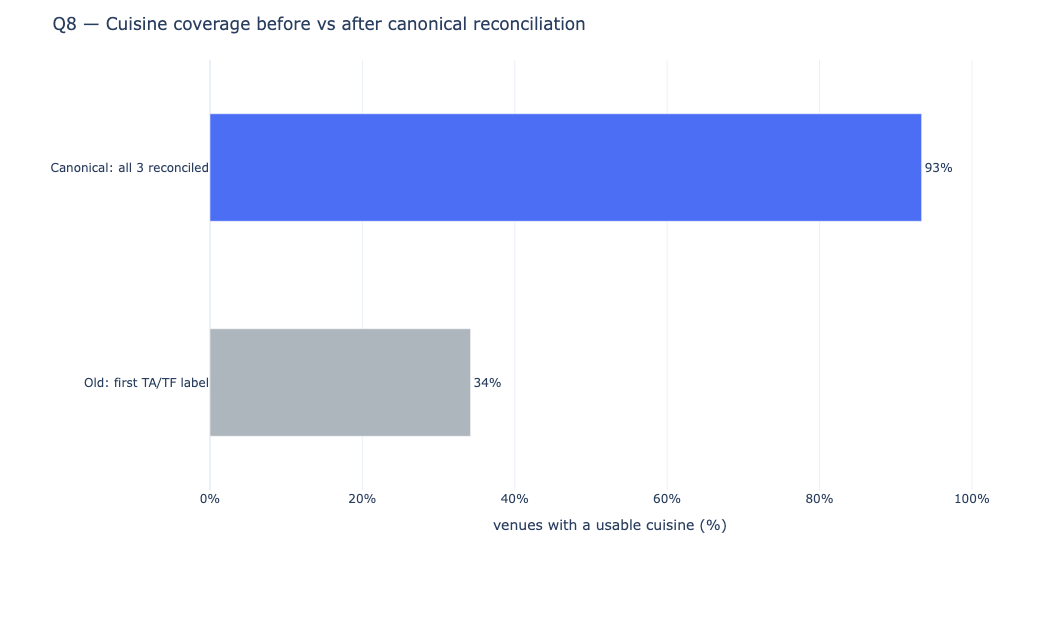

In [2]:
# The data-fix story gets its own image: cuisine coverage before vs after
# reconciling all three platform vocabularies into one canonical taxonomy.
cov = publish(run(queries.q8_coverage()), "q8_cuisine_coverage",
              "Q8 — Cuisine coverage before/after canonical reconciliation.").iloc[0]

# Shared style for centered, on-figure footnote captions (house style).
FOOT = dict(xref="paper", yref="paper", x=0.5, xanchor="center", yanchor="top",
            align="center", showarrow=False, font=dict(size=11.5, color="#495057"))

fig0 = go.Figure()
for name, val, col in [("Old: first TA/TF label", cov.pct_old, "#ADB5BD"),
                       ("Canonical: all 3 reconciled", cov.pct_canonical, "#4C6EF5")]:
    fig0.add_bar(x=[val], y=[name], orientation="h", marker_color=col, width=0.5,
                 text=[f"{val:.0f}%"], textposition="outside")
fig0.add_annotation(y=-0.32, **FOOT,
    text=(f"<b>One canonical taxonomy nearly tripled cuisine coverage.</b> The old field took only "
          f"Tripadvisor/TheFork's first label and split<br>the same cuisine across spellings; mapping every "
          f"raw label to one shared list and reconciling all three vocabularies per<br>venue lifted coverage "
          f"{cov.pct_old:.0f}% → {cov.pct_canonical:.0f}% ({int(cov.old_distinct_labels)} raw labels "
          f"→ {int(cov.canonical_buckets)} buckets) — Google's near-complete cuisine field finally counts."))
fig0.update_xaxes(title="venues with a usable cuisine (%)", ticksuffix="%", range=[0, 105])
fig0.update_layout(title="Q8 — Cuisine coverage before vs after canonical reconciliation",
                   template="plotly_white", showlegend=False,
                   width=1000, height=380, margin=dict(l=210, r=40, t=60, b=130))
fig0.show()

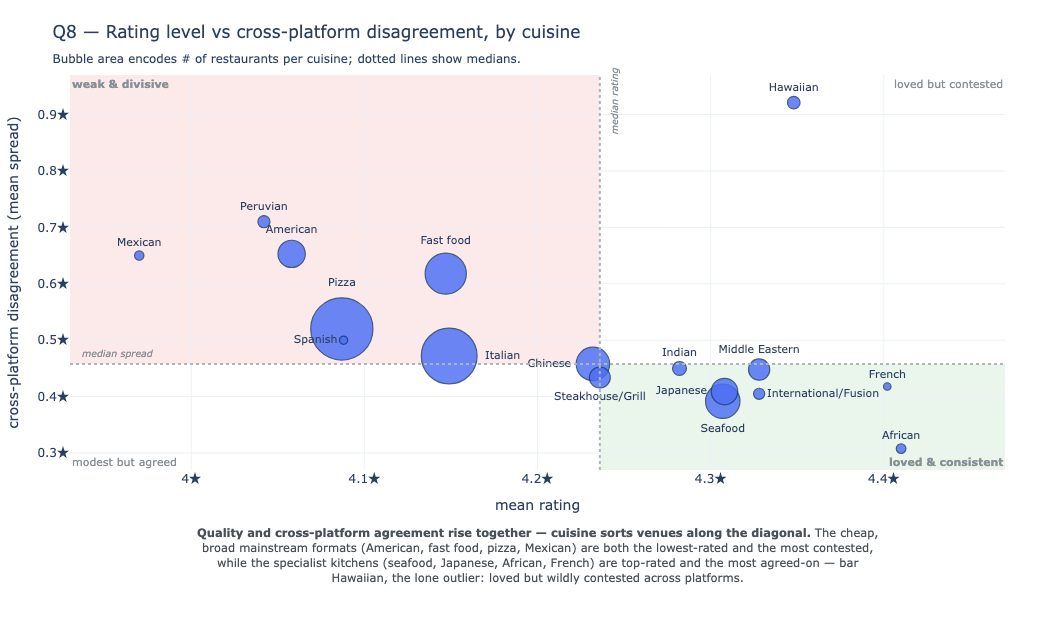

,cuisine,restaurants,mean_rating,multi_platform,mean_range,median_range,median_reviews,mean_reviews,mean_price,priced,tp
1,Pizza,1463,4.087,861,0.520,0.40,476.0,1087.0,1.53,1133,top center
2,Italian,1176,4.149,1013,0.472,0.40,450.0,1083.0,1.87,1032,middle right
3,Fast food,640,4.147,207,0.618,0.50,181.0,693.0,1.31,352,top center
4,Seafood,446,4.307,381,0.392,0.40,1099.0,1621.0,2.32,423,bottom center
5,Chinese,423,4.232,312,0.458,0.40,458.0,922.0,1.58,318,middle left
6,American,281,4.058,139,0.653,0.50,476.0,1022.0,1.71,195,top center
7,Japanese,265,4.308,156,0.409,0.30,510.0,1060.0,2.06,205,middle left
8,Middle Eastern,170,4.328,49,0.448,0.40,198.0,408.0,1.30,97,top center
9,Steakhouse/Grill,165,4.236,125,0.434,0.40,1153.0,1666.0,2.19,153,bottom center
10,Indian,73,4.282,51,0.450,0.30,533.0,1042.0,1.80,51,top center


In [3]:
# Headline: rating level vs cross-platform disagreement, one point per cuisine.
# Café/Bakery/Bar is a format (and the largest bucket), not a cuisine -> excluded here;
# require >= 20 multi-platform venues so the spread is reliable.
q8 = publish(run(queries.q8_cuisine(top_n=30)), "q8_cuisine_consistency",
             "Q8 — Mean rating and cross-platform spread by canonical cuisine.")
d = q8[(q8.cuisine != "Café/Bakery/Bar") & (q8.multi_platform >= 20)].copy()
mx, my = d.mean_rating.median(), d.mean_range.median()

# Nudge labels apart in the dense high-rating / low-spread cluster.
POS = {"Seafood": "bottom center", "Japanese": "middle left",
       "International/Fusion": "middle right", "Middle Eastern": "top center",
       "Chinese": "middle left", "Steakhouse/Grill": "bottom center",
       "Italian": "middle right", "Indian": "top center", "Spanish": "middle left"}
d["tp"] = d.cuisine.map(POS).fillna("top center")

fig = px.scatter(d, x="mean_rating", y="mean_range", size="restaurants", text="cuisine",
                 size_max=44, template="plotly_white")
fig.update_traces(textposition=d["tp"], marker_color="#4C6EF5", marker_opacity=0.82,
                  marker_line_color="#1B3A6B", marker_line_width=1.2, textfont_size=11,
                  cliponaxis=False, showlegend=False)
x0, x1, y0, y1 = 3.93, 4.47, 0.27, 0.97
fig.add_shape(type="rect", x0=mx, x1=x1, y0=y0, y1=my, fillcolor="#2F9E44",
              opacity=0.10, line_width=0, layer="below")
fig.add_shape(type="rect", x0=x0, x1=mx, y0=my, y1=y1, fillcolor="#E03131",
              opacity=0.10, line_width=0, layer="below")
fig.add_vline(x=mx, line_dash="dot", line_color="#ADB5BD")
fig.add_hline(y=my, line_dash="dot", line_color="#ADB5BD")
qa = dict(showarrow=False, font=dict(size=11, color="#868E96"), xref="x", yref="y")
fig.add_annotation(x=x1, y=y0, text="<b>loved &amp; consistent</b>", xanchor="right", yanchor="bottom", **qa)
fig.add_annotation(x=x0, y=y1, text="<b>weak &amp; divisive</b>", xanchor="left", yanchor="top", **qa)
fig.add_annotation(x=x0, y=y0, text="modest but agreed", xanchor="left", yanchor="bottom", **qa)
fig.add_annotation(x=x1, y=y1, text="loved but contested", xanchor="right", yanchor="top", **qa)

# Label the reference lines directly; keep them quiet so they do not compete with cuisines.
ml = dict(showarrow=False, font=dict(size=9.5, color="#868E96", style="italic"),
          xref="x", yref="y")
fig.add_annotation(x=mx + 0.004, y=y1 - 0.045, text="median rating", textangle=-90,
                   xanchor="left", yanchor="middle", **ml)
fig.add_annotation(x=x0 + 0.006, y=my + 0.006, text="median spread",
                   xanchor="left", yanchor="bottom", **ml)

# Bottom storytelling caption (house FOOT style): the diagonal is the story.
fig.add_annotation(y=-0.135, **FOOT,
    text=("<b>Quality and cross-platform agreement rise together — cuisine sorts venues along the diagonal.</b> The cheap,"
          "<br>broad mainstream formats (American, fast food, pizza, Mexican) are both the lowest-rated and the most contested,"
          "<br>while the specialist kitchens (seafood, Japanese, African, French) are top-rated and the most agreed-on — bar"
          "<br>Hawaiian, the lone outlier: loved but wildly contested across platforms."))

fig.update_xaxes(title="mean rating", ticksuffix="★", range=[x0, x1])
fig.update_yaxes(title="cross-platform disagreement (mean spread)", ticksuffix="★", range=[y0, y1])
fig.update_layout(title=("Q8 — Rating level vs cross-platform disagreement, by cuisine"
                         "<br><sub>Bubble area encodes # of restaurants per cuisine; dotted lines show medians.</sub>"),
                  width=1050, height=680, margin=dict(l=70, r=45, t=75, b=150), showlegend=False)
fig.show()
d

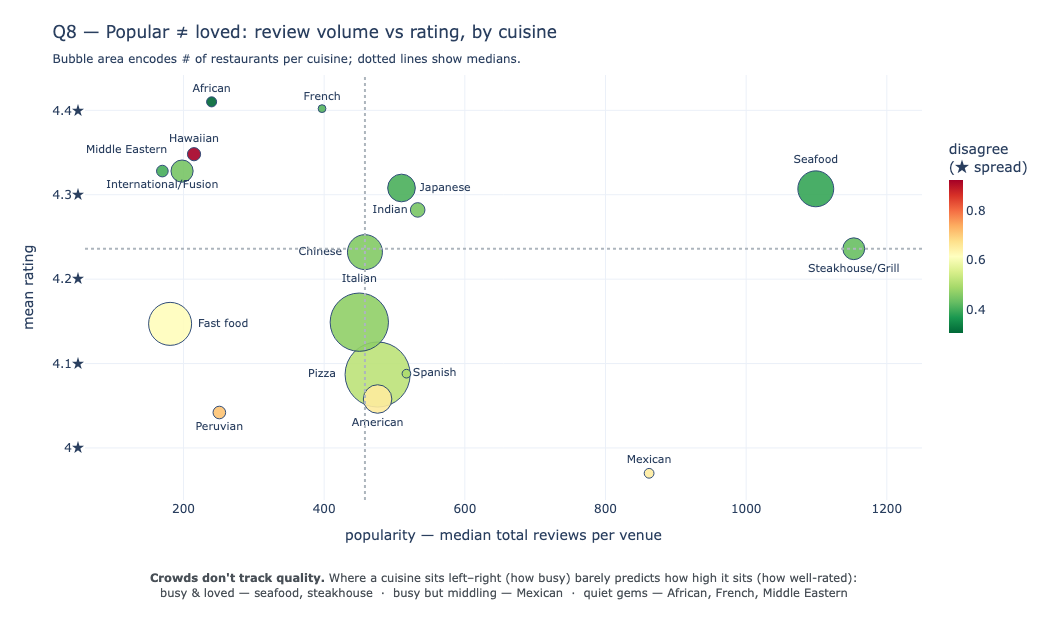

In [4]:
# Does popularity buy a better rating? Plot each cuisine's typical review volume
# against its mean rating; colour by cross-platform disagreement.
p = d.copy()
PP = {"Seafood": "top center", "Steakhouse/Grill": "bottom center", "Mexican": "top center",
      "Japanese": "middle right", "Indian": "middle left", "Pizza": "middle left",
      "Italian": "top center", "American": "bottom center", "Chinese": "middle left",
      "Spanish": "middle right", "African": "top center", "French": "top center",
      "Middle Eastern": "top left", "Hawaiian": "top center",
      "International/Fusion": "bottom center", "Peruvian": "bottom center", "Fast food": "middle right"}
p["tp"] = p.cuisine.map(PP).fillna("top center")

fig3 = px.scatter(p, x="median_reviews", y="mean_rating", size="restaurants", text="cuisine",
                  color="mean_range", color_continuous_scale="RdYlGn_r", size_max=46,
                  template="plotly_white")
fig3.update_traces(textposition=p["tp"], marker_line_color="#1B3A6B", marker_line_width=1,
                   marker_opacity=0.9, textfont_size=11, cliponaxis=False)
fig3.add_vline(x=p.median_reviews.median(), line_dash="dot", line_color="#ADB5BD")
fig3.add_hline(y=p.mean_rating.median(), line_dash="dot", line_color="#ADB5BD")
# Centered takeaway footnote along the bottom (reuses the shared FOOT style).
fig3.add_annotation(y=-0.16, **FOOT,
    text=("<b>Crowds don't track quality.</b> Where a cuisine sits left–right (how busy) barely predicts how high "
          "it sits (how well-rated):<br>busy &amp; loved — seafood, steakhouse&nbsp;&nbsp;·&nbsp;&nbsp;"
          "busy but middling — Mexican&nbsp;&nbsp;·&nbsp;&nbsp;"
          "quiet gems — African, French, Middle Eastern"))
fig3.update_xaxes(title="popularity — median total reviews per venue", range=[60, 1250])
fig3.update_yaxes(title="mean rating", ticksuffix="★")
fig3.update_layout(title=("Q8 — Popular ≠ loved: review volume vs rating, by cuisine"
                          "<br><sub>Bubble area encodes # of restaurants per cuisine; dotted lines show medians.</sub>"),
                   width=1050, height=640, margin=dict(l=85, r=30, t=75, b=120),
                   coloraxis_colorbar=dict(title="disagree<br>(★ spread)", thickness=14, len=0.5,
                                           x=1.02, y=0.62))
fig3.show()

### The price angle

Price is an **ordinal tier** (€ < €€ < €€€ < €€€€), not an interval number, and its link to rating
turned out to be a **step, not a slope**: € and €€ are statistically indistinguishable (Mann-Whitney
effect r ≈ 0.07), with a small lift only at the rare €€€/€€€€ tiers (r ≈ 0.25). A regression line
would over-claim a continuous slope — and fitting it to cuisine means rather than venues inflates the
R² ~9× (the ecological fallacy). So instead of averaging the ordinal codes, we keep price categorical
and read the relationship as **composition** — the rating-band mix *within* each tier — paired with
how rare each tier is, so the reader sees both that the premium step exists and that it barely applies.

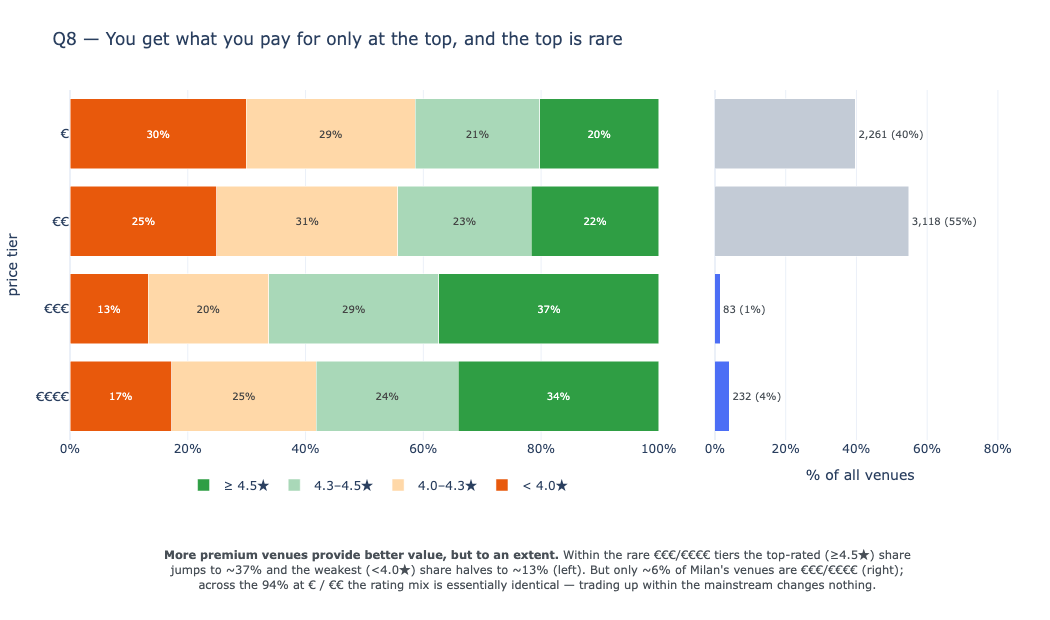

,tier,< 4.0★,4.0–4.3★,4.3–4.5★,≥ 4.5★
0,€,29.9,28.7,21.1,20.3
1,€€,25.0,30.7,22.7,21.6
2,€€€,13.3,20.5,28.9,37.3
3,€€€€,17.2,24.6,24.1,34.1


In [5]:
# Price angle — self-contained main chart. Price is an ordinal tier (€…€€€€) whose link to rating is
# a *step, not a slope* (€≈€€, a small lift only at €€€+), so we keep it categorical and read it as
# composition. Two shared-y panels: LEFT = rating-band mix within each tier (the effect), RIGHT = how
# many venues sit in each tier (premium is rare). Pairing them shows the step is real but barely applies.
from plotly.subplots import make_subplots

TICKS = {1: "€", 2: "€€", 3: "€€€", 4: "€€€€"}
rows = run(queries.q8_price_rows())
BANDS = [("< 4.0★", -1, 4.0, "#E8590C"), ("4.0–4.3★", 4.0, 4.3, "#FFD8A8"),
         ("4.3–4.5★", 4.3, 4.5, "#A9D8B8"), ("≥ 4.5★", 4.5, 9, "#2F9E44")]
REG = {1: "#C3CBD6", 2: "#C3CBD6", 3: "#4C6EF5", 4: "#4C6EF5"}  # mainstream greyed, premium accented

def _share(t, lo, hi):
    s = rows.rating[rows.price_tier == t]
    return 100 * ((s >= lo) & (s < hi)).mean()

counts = {t: int((rows.price_tier == t).sum()) for t in (1, 2, 3, 4)}
total = sum(counts.values())
share = {t: 100 * counts[t] / total for t in (1, 2, 3, 4)}

# Published tables: per-tier rating summary + the rating-band composition.
publish(rows.groupby("price_tier").rating.agg(
            n="size", median="median", mean="mean",
            q1=lambda s: s.quantile(.25), q3=lambda s: s.quantile(.75)).round(3).reset_index(),
        "q8_price_tier_rating", "Q8 — Rating distribution by price tier (all priced venues).")
band_tbl = publish(
    pd.DataFrame({lab: [_share(t, lo, hi) for t in (1, 2, 3, 4)] for lab, lo, hi, _ in BANDS},
                 index=[TICKS[t] for t in (1, 2, 3, 4)]).round(1).rename_axis("tier").reset_index(),
    "q8_price_rating_bands", "Q8 — Share of venues by rating band, per price tier.")

fig_price = make_subplots(rows=1, cols=2, shared_yaxes=True, column_widths=[0.67, 0.33],
                          horizontal_spacing=0.06)
# LEFT — rating-band composition within each tier (the effect)
for lab, lo, hi, col in BANDS:
    fig_price.add_bar(row=1, col=1, y=[TICKS[t] for t in (1, 2, 3, 4)],
        x=[_share(t, lo, hi) for t in (1, 2, 3, 4)], orientation="h", name=lab, marker_color=col,
        text=[f"{_share(t, lo, hi):.0f}%" if _share(t, lo, hi) >= 8 else "" for t in (1, 2, 3, 4)],
        textposition="inside", insidetextanchor="middle", textfont=dict(size=10))
# RIGHT — how many venues per tier (premium is rare)
fig_price.add_bar(row=1, col=2, y=[TICKS[t] for t in (1, 2, 3, 4)], x=[share[t] for t in (1, 2, 3, 4)],
    orientation="h", marker_color=[REG[t] for t in (1, 2, 3, 4)], cliponaxis=False, showlegend=False,
    text=[f"{counts[t]:,} ({share[t]:.0f}%)" for t in (1, 2, 3, 4)], textposition="outside",
    textfont=dict(size=10, color="#495057"))
fig_price.add_annotation(y=-0.30, **FOOT,
    text=("<b>More premium venues provide better value, but to an extent.</b> Within the rare €€€/€€€€ tiers the "
          "top-rated (≥4.5★) share<br>jumps to ~37% and the weakest (&lt;4.0★) share halves to ~13% (left). But only "
          "~6% of Milan's venues are €€€/€€€€ (right);<br>across the 94% at € / €€ the rating mix is essentially "
          "identical — trading up within the mainstream changes nothing."))
fig_price.update_yaxes(categoryorder="array", categoryarray=[TICKS[t] for t in (4, 3, 2, 1)],
                       title="price tier", tickfont=dict(size=13), row=1, col=1)
fig_price.update_xaxes(ticksuffix="%", range=[0, 100], row=1, col=1)
fig_price.update_xaxes(title="% of all venues", ticksuffix="%", range=[0, 82], row=1, col=2)
fig_price.update_layout(barmode="stack", template="plotly_white", width=1050, height=540,
    margin=dict(l=70, r=45, t=90, b=180),
    legend=dict(orientation="h", yanchor="bottom", y=-0.17, x=0.33, xanchor="center", title_text=""),
    title=("Q8 — You get what you pay for only at the top, and the top is rare"))
fig_price.show()
band_tbl

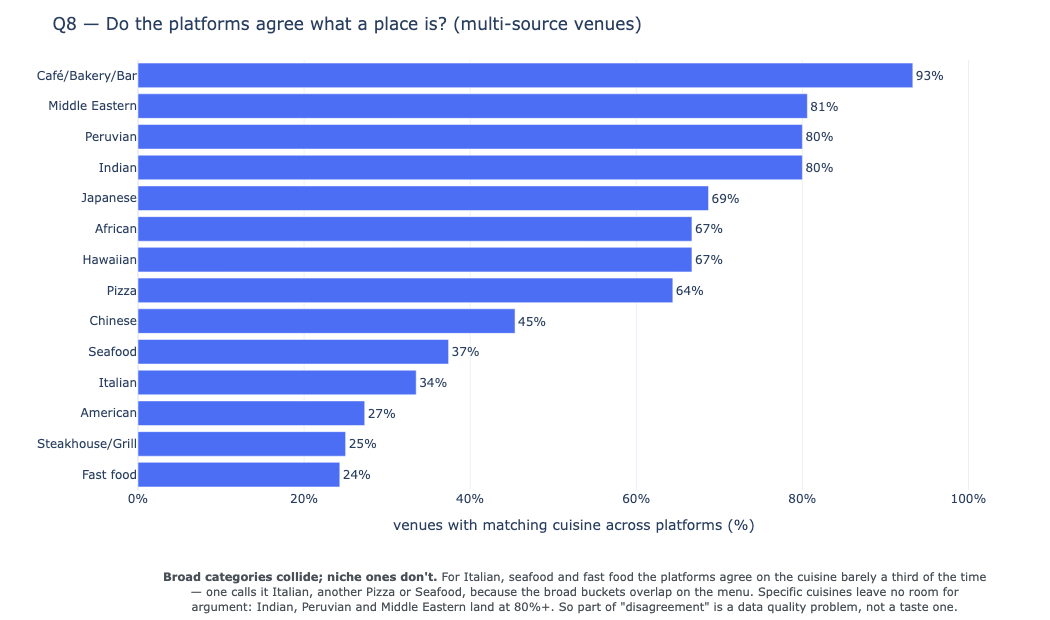

,cuisine,multi_source,pct_agree
0,Café/Bakery/Bar,30,93.3
1,Middle Eastern,31,80.6
2,Indian,45,80.0
3,Peruvian,25,80.0
4,Japanese,147,68.7
5,Hawaiian,21,66.7
6,African,21,66.7
7,Pizza,807,64.4
8,Chinese,273,45.4
9,Seafood,329,37.4


In [6]:
# Bonus finding: do the platforms even agree what a place *is*? For venues carrying a
# cuisine on >= 2 platforms, how often do their primary buckets match?
agr = publish(run(queries.q8_cuisine_agreement()), "q8_cuisine_agreement",
              "Q8 — Cross-source agreement on the primary cuisine, by bucket.")
a = agr.sort_values("pct_agree")
fig2 = px.bar(a, x="pct_agree", y="cuisine", orientation="h", text="pct_agree",
              template="plotly_white")
fig2.update_traces(marker_color="#4C6EF5", texttemplate="%{text:.0f}%", textposition="outside")
fig2.add_annotation(y=-0.18, **FOOT,
    text=("<b>Broad categories collide; niche ones don't.</b> For Italian, seafood and fast food the platforms "
          "agree on the cuisine barely a third of the time<br>— one calls it Italian, another Pizza or Seafood, "
          "because the broad buckets overlap on the menu. Specific cuisines leave no room for<br>argument: "
          "Indian, Peruvian and Middle Eastern land at 80%+. So part of \"disagreement\" is a data quality "
          "problem, not a taste one."))
fig2.update_xaxes(title="venues with matching cuisine across platforms (%)", ticksuffix="%", range=[0, 105])
fig2.update_yaxes(title="")
fig2.update_layout(title="Q8 — Do the platforms agree what a place is? (multi-source venues)",
                   width=1000, height=620, margin=dict(l=120, r=40, t=60, b=130))
fig2.show()
agr

**Answer (Q8): yes — cuisine moves both the rating *level* and the cross-platform
*consistency*, but only after the cuisine field is fixed.** Reconciling the three platform
vocabularies into a canonical taxonomy lifts cuisine coverage from ~34% to ~93% and collapses
73 raw labels into 31 buckets — without it the question can't be answered honestly (the
modal cuisine was split across `Italiana`/`Italiano` and Google was ignored).

On the clean buckets: high-throughput, broad-appeal categories (**pizza**, **fast food**,
**American**) sit at lower ratings *and* the widest cross-platform disagreement, while
**seafood**, **Japanese** and **African** are both top-rated and the most consistent.

Two further cuts sharpen the picture. **Popularity doesn't buy quality** — the most-reviewed
cuisines split between loved (seafood, steakhouse, ~4.3★) and merely busy (Mexican, a third of a
star lower); the average-reviewed mainstream (pizza, Italian) is unremarkable on both axes, while
quiet niche cuisines (African, French, Middle Eastern) score highest on a fraction of the reviews.
**Price buys quality only at the top** — € and €€ venues are statistically indistinguishable
(Mann-Whitney r ≈ 0.07), and only the rare €€€/€€€€ tiers (~6% of venues) show a real lift, where
the top-rated (≥4.5★) share jumps from ~21% to ~37%; the cheap Middle Eastern and African kitchens
that rate among the very best are the standout value-for-money exception.

A final effect surfaces from `cuisine_agreement`: the platforms disagree on *what a place even is*
far more for broad categories (Italian/Seafood ≈ a third agreement) than for niche cuisines
(Indian, Peruvian, Middle Eastern 80%+) — the disagreement is partly a labelling problem, not
just a rating one. See `q8_cuisine_consistency`, `q8_cuisine_agreement`, `q8_cuisine_coverage`.